In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv('online_shoppers_intention.csv')
print(df.shape)
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.shape      # → Kitni rows, kitne columns hain
# df.columns    # → Kaunse kaunse columns hain
# df.dtypes     # → Number hai ya text hai har column
# df.isnull().sum  # → Koi data missing toh nahi

(12330, 18)

In [4]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [5]:
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

In [6]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [7]:
df.isnull().sum().sum()

0

## Target_Variable


In [8]:
# Target variable check 
print("Revenue column ki values:")
print(df['Revenue'].value_counts())

print("\nPercentage mein:")
print(df['Revenue'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Revenue column ki values:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Percentage mein:
Revenue
False    84.5%
True     15.5%
Name: proportion, dtype: object


## Visualization

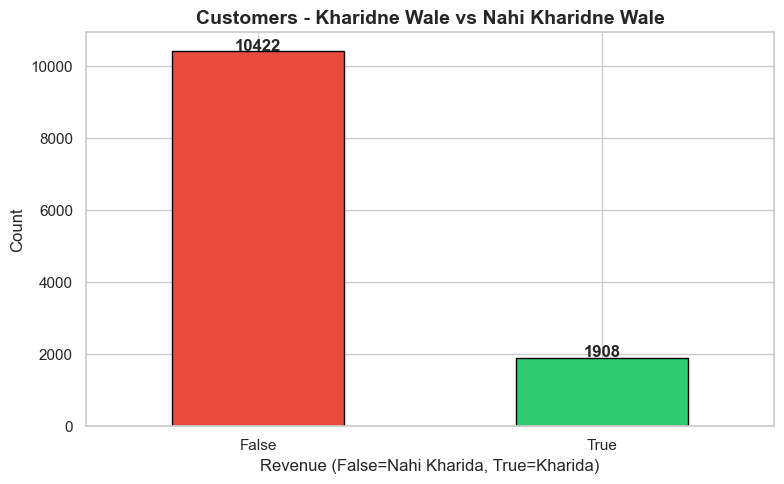

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
ax = df['Revenue'].value_counts().plot(
    kind='bar',
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black'
)

plt.title('Customers - Kharidne Wale vs Nahi Kharidne Wale', 
          fontsize=14, fontweight='bold')
plt.xlabel('Revenue (False=Nahi Kharida, True=Kharida)')
plt.ylabel('Count')
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()+10),
                ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


###  — Synthetic Columns Add Karna


In [10]:
import numpy as np

# Returning visitor ko recent purchase assign karo
df['Last_Purchase_Days_Ago'] = np.where(
    df['VisitorType'] == 'Returning_Visitor',
    np.random.randint(1, 90, size=len(df)),
    np.random.randint(90, 365, size=len(df))
)

# Age add karo
np.random.seed(42)
df['Age'] = np.random.randint(18, 65, size=len(df))

# Average Order Value add karo
df['Avg_Order_Value'] = np.round(
    df['PageValues'] * 100 + np.random.uniform(500, 5000, size=len(df)), 2
)

print("✅ 3 Naye Columns Add Ho Gaye!")
print(df[['Last_Purchase_Days_Ago', 'Age', 'Avg_Order_Value']].head(10))

# ```

# **Shift + Enter dabaao**

# ---

# ## Ye 3 Columns Kyun Aur Kaise Banayi?

    
# ```
# Age:
# Bilkul random — 18 se 65 ke beech
# Real mein bhi customers ki age isi range mein hoti hai

# Last_Purchase_Days_Ago:
# Returning Visitor → 1-90 din  (recently aaya tha)
# New Visitor       → 90-365 din (pehli baar aaya)
# Logic: Jo wapas aaya wo recently kharida hoga

# Avg_Order_Value:
# PageValues se link kiya — 
# Jo pages zyada value ke dekhe uska order zyada hoga
# Upar se random amount add kiya realistic banane ke liye

✅ 3 Naye Columns Add Ho Gaye!
   Last_Purchase_Days_Ago  Age  Avg_Order_Value
0                      39   56          1363.26
1                       9   46          2002.17
2                      52   32          3774.68
3                       3   60          3511.66
4                      56   25           823.17
5                      61   38          3862.92
6                      73   56           738.71
7                      62   36          2943.17
8                       4   40          1670.28
9                      87   28          3144.61


### EDA (Exploring Data Analysis) 🔍

In [11]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Last_Purchase_Days_Ago,Age,Avg_Order_Value
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586,71.343715,40.963666,3331.383237
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169,73.740222,13.465558,2257.561223
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,18.000000,500.040000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,27.000000,29.000000,1869.465000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,53.000000,41.000000,3087.575000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000,79.000000,53.000000,4289.782500
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000,364.000000,64.000000,38391.150000


###  — Numerical Features Distribution

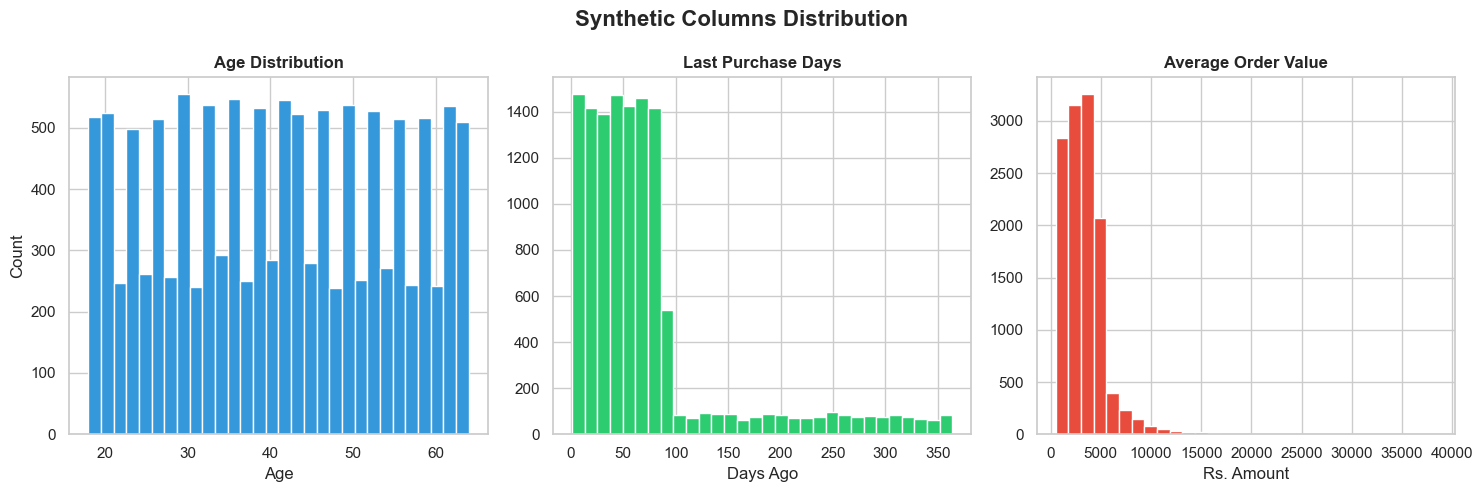

In [12]:
# Apne 3 synthetic columns visualize karo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age
axes[0].hist(df['Age'], bins=30, color='#3498db', edgecolor='white')
axes[0].set_title('Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Last Purchase Days
axes[1].hist(df['Last_Purchase_Days_Ago'], bins=30, 
             color='#2ecc71', edgecolor='white')
axes[1].set_title('Last Purchase Days', fontweight='bold')
axes[1].set_xlabel('Days Ago')

# Avg Order Value
axes[2].hist(df['Avg_Order_Value'], bins=30, 
             color='#e74c3c', edgecolor='white')
axes[2].set_title('Average Order Value', fontweight='bold')
axes[2].set_xlabel('Rs. Amount')

plt.suptitle('Synthetic Columns Distribution', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### — Correlation Heatmap 

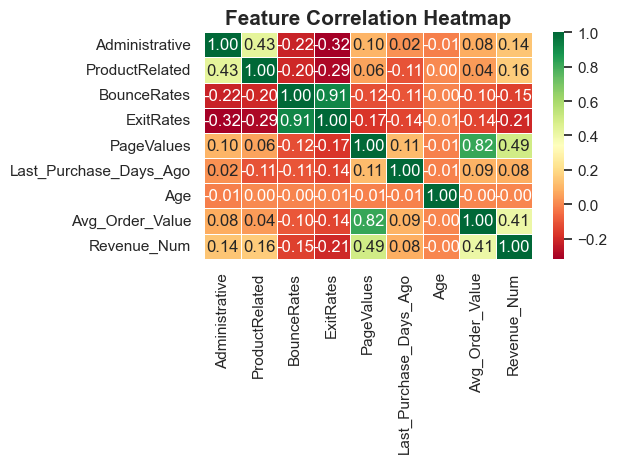

In [13]:
# Sirf numerical columns lo
num_cols = ['Administrative', 'ProductRelated', 
            'BounceRates', 'ExitRates', 'PageValues',
            'Last_Purchase_Days_Ago', 'Age', 'Avg_Order_Value']

# Revenue ko 0/1 mein badlo
df['Revenue_Num'] = df['Revenue'].astype(int)

# plt.figure(figsize=(10, 5))
corr = df[num_cols + ['Revenue_Num']].corr()

sns.heatmap(corr, 
            annot=True,      # Numbers dikhao
            fmt='.2f',       # 2 decimal
            cmap='RdYlGn',   # Red=Negative, Green=Positive
            linewidths=0.5)

plt.title('Feature Correlation Heatmap', 
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
# ```

# **Shift + Enter dabaao**

# ---

## Heatmap Ko Kaise Padhein?
# ```
# Colors ka matlab:

# 🟢 Green (+ value) → Dono saath badhte hain
# 🔴 Red   (- value) → Ek badhe toh doosra ghate
# ⬜ White (0 value) → Koi relation nahi

# Numbers:
# +1.0 = Perfect positive relation
# -1.0 = Perfect negative relation
#  0.0 = Koi relation nahi
# ```

# ## Revenue_Num Wali Row Dekho:
# ```
# Ye sabse important row hai
# Ye batayegi konsa feature
# target se zyada related hai
# 
# Jis feature ka number
# +0.3 se upar ya -0.3 se neeche
# Woh important feature hai!

 ## — Data Preprocessing

### — Encoding Categorical Columns

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Categorical columns encode karo
df['Month'] = le.fit_transform(df['Month'])
df['VisitorType'] = le.fit_transform(df['VisitorType'])
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

print("✅ Encoding Complete!")
print(df[['Month', 'VisitorType', 'Weekend', 'Revenue']].head(10))
# ```

# **Shift + Enter dabaao**

# ---

# ## Encoding Kyun Kiya?
# ```
# Model sirf numbers samajhta hai

# Pehle:
# Month       = "Feb", "Mar", "Dec"
# VisitorType = "New_Visitor", "Returning_Visitor"
# Weekend     = True, False

# Baad mein:
# Month       = 0, 1, 2, 3...
# VisitorType = 0, 1, 2
# Weekend     = 0, 1
# ```

# ---

# ## 9.2 — Features Aur Target Alag Karo

# ### Markdown Cell:
# ```
# ### Step 9.2 — X aur y Split

✅ Encoding Complete!
   Month  VisitorType  Weekend  Revenue
0      2            2        0        0
1      2            2        0        0
2      2            2        0        0
3      2            2        0        0
4      2            2        1        0
5      2            2        0        0
6      2            2        0        0
7      2            2        1        0
8      2            2        0        0
9      2            2        0        0


### — Features and target (Alag)

 ### — X aur y Split

In [15]:
# Revenue_Num drop karo (duplicate hai)
df = df.drop('Revenue_Num', axis=1)

# X = Features (input)
# y = Target (output)
X = df.drop('Revenue', axis=1)
y = df['Revenue']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\ny ki values:\n{y.value_counts()}")
# ```

# **Shift + Enter dabaao**

# ---

# ## 9.3 — Train Test Split

# ### Markdown Cell:
# ```
# ### Step 9.3 — Train Test Split

X shape: (12330, 20)
y shape: (12330,)

y ki values:
Revenue
0    10422
1     1908
Name: count, dtype: int64


## — Train Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% test
    random_state=42,    # Same result har baar
    stratify=y          # Balance maintain karo
)

print(f"Training data:   {X_train.shape}")
print(f"Testing data:    {X_test.shape}")
print(f"\nTrain class balance:\n{y_train.value_counts()}")
print(f"\nTest class balance:\n{y_test.value_counts()}")
# ```

# **Shift + Enter dabaao**

# ---

# ## 9.4 — SMOTE Lagao

# ### Markdown Cell:
# ```
# ### Step 9.4 — SMOTE (Imbalance Fix Karo)

Training data:   (9864, 20)
Testing data:    (2466, 20)

Train class balance:
Revenue
0    8338
1    1526
Name: count, dtype: int64

Test class balance:
Revenue
0    2084
1     382
Name: count, dtype: int64


 ### — SMOTE 

In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("✅ SMOTE Complete!")
print(f"\nPehle:\n{y_train.value_counts()}")
print(f"\nBaad mein:\n{y_train_bal.value_counts()}")
# ```

# **Shift + Enter dabaao**

# ---

# ## Expected Output:
# ```
# Pehle:
# 0    8337   ← Zyada
# 1    1529   ← Kam

# Baad mein:
# 0    8337
# 1    8337   ← Equal ho gaya ✅

✅ SMOTE Complete!

Pehle:
Revenue
0    8338
1    1526
Name: count, dtype: int64

Baad mein:
Revenue
0    8338
1    8338
Name: count, dtype: int64


##  — Model Training

###  — Evaluation Function

In [18]:
from sklearn.metrics import (accuracy_score, precision_score, 
                              recall_score, f1_score, roc_auc_score)

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    
    # Model train karo
    model.fit(X_tr, y_tr)
    
    # Predict karo
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    
    # Results store karo
    results = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred), 3),
        'Precision': round(precision_score(y_te, y_pred), 3),
        'Recall'   : round(recall_score(y_te, y_pred), 3),
        'F1-Score' : round(f1_score(y_te, y_pred), 3),
        'ROC-AUC'  : round(roc_auc_score(y_te, y_prob), 3)
    }
    
    print(f"✅ {name} Done!")
    return results, model

print("✅ Function Ready!")
# ```

# **Shift + Enter dabaao**

# ---

# ## 10.2 — Logistic Regression

# ### Markdown Cell:
# ```
# ### Step 10.2 — Logistic Regression (Baseline Model)

✅ Function Ready!


### — Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression

lr_results, lr_model = evaluate_model(
    'Logistic Regression',
    LogisticRegression(random_state=42, max_iter=1000),
    X_train_bal, y_train_bal, 
    X_test, y_test
)

print(lr_results)
# ```

# **Shift + Enter dabaao**

# ---

# ## 10.3 — Random Forest

# ### Markdown Cell:
# ```
# ### Step 10.3 — Random Forest

✅ Logistic Regression Done!
{'Model': 'Logistic Regression', 'Accuracy': 0.872, 'Precision': 0.572, 'Recall': 0.699, 'F1-Score': 0.629, 'ROC-AUC': 0.867}


C:\Users\Leads University\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


###  — Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_results, rf_model = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_bal, y_train_bal,
    X_test, y_test
)

print(rf_results)
# ```

# **Shift + Enter dabaao**

# ---

# ## 10.4 — XGBoost

# ### Markdown Cell:
# ```
# ### Step 10.4 — XGBoost

✅ Random Forest Done!
{'Model': 'Random Forest', 'Accuracy': 0.883, 'Precision': 0.604, 'Recall': 0.715, 'F1-Score': 0.655, 'ROC-AUC': 0.91}


###  — XGBoost

In [21]:
from xgboost import XGBClassifier

xgb_results, xgb_model = evaluate_model(
    'XGBoost',
    XGBClassifier(random_state=42, eval_metric='logloss'),
    X_train_bal, y_train_bal,
    X_test, y_test
)

print(xgb_results)
# ```

# **Shift + Enter dabaao**

# ---

# ## Teeno Models Kyun?
# ```
# Logistic Regression → Simple baseline
#                       Dekhte hain basic model kitna karta hai

# Random Forest       → Zyada powerful
#                       100 trees mil ke decide karte hain

# XGBoost             → Sabse powerful
#                       Har baar apni galtiyaan fix karta hai

✅ XGBoost Done!
{'Model': 'XGBoost', 'Accuracy': 0.882, 'Precision': 0.606, 'Recall': 0.686, 'F1-Score': 0.644, 'ROC-AUC': 0.9}


##  — Models Comparison Visualization

### — Results Table

In [22]:
# Teeno results ko ek table mein dikhao
results_df = pd.DataFrame([lr_results, rf_results, xgb_results])
print("📊 Model Comparison Table:")
print(results_df.to_string(index=False))
#```

# **Shift + Enter dabaao**

# ---

# ## 11.2 — Bar Chart Comparison

# ### Markdown Cell:
# ```
# ### Step 11.2 — Bar Chart Comparison

📊 Model Comparison Table:
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.872      0.572   0.699     0.629    0.867
      Random Forest     0.883      0.604   0.715     0.655    0.910
            XGBoost     0.882      0.606   0.686     0.644    0.900


### — Bar Chart Comparison

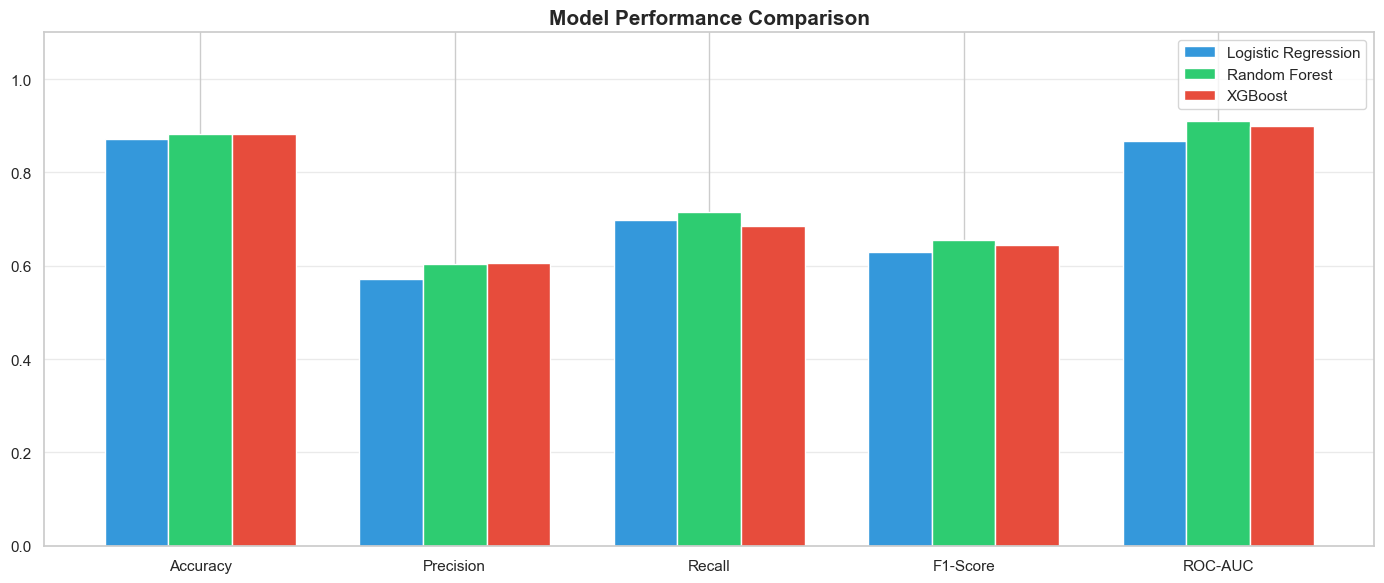

In [23]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

# Teeno models ki bars
ax.bar(x - width, results_df.iloc[0][metrics], 
       width, label='Logistic Regression', color='#3498db')
ax.bar(x,         results_df.iloc[1][metrics], 
       width, label='Random Forest',       color='#2ecc71')
ax.bar(x + width, results_df.iloc[2][metrics], 
       width, label='XGBoost',             color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_title('Model Performance Comparison', 
             fontsize=15, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()
# ```

# **Shift + Enter dabaao**

# ---

# ## 11.3 — Confusion Matrix

# ### Markdown Cell:
# ```
# ### Step 11.3 — Confusion Matrix (Best Model — Random Forest)

###  — Confusion Matrix

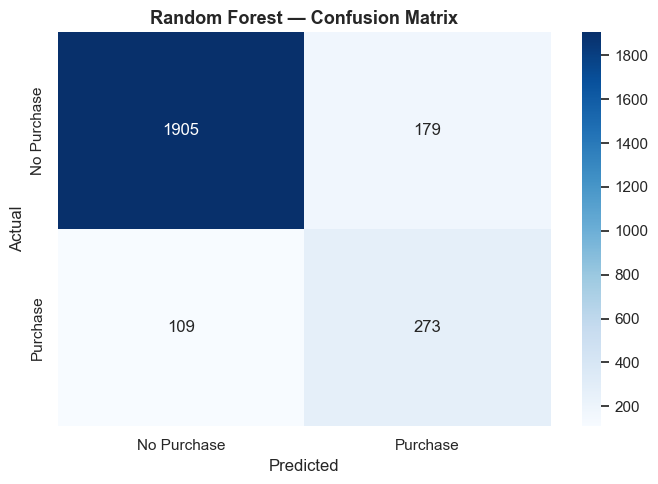

✅ Sahi Predict (No Purchase): 1905
✅ Sahi Predict (Purchase):    273
❌ Galat (False Alarm):        179
❌ Miss Kiya (Revenue Loss):   109


In [24]:
from sklearn.metrics import confusion_matrix

y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])

plt.title('Random Forest — Confusion Matrix', 
          fontweight='bold', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Numbers explain karo
tn, fp, fn, tp = cm.ravel()
print(f"✅ Sahi Predict (No Purchase): {tn}")
print(f"✅ Sahi Predict (Purchase):    {tp}")
print(f"❌ Galat (False Alarm):        {fp}")
print(f"❌ Miss Kiya (Revenue Loss):   {fn}")
# ```

# **Shift + Enter dabaao**

# ---

# ## Confusion Matrix Ko Kaise Samjhein:
# ```
#                  Predicted
#                  No      Yes
# Actual  No  [  TN  |  FP  ]
#         Yes [  FN  |  TP  ]

# TN = Sahi bola "Nahi kharidega" ✅
# TP = Sahi bola "Kharidega"      ✅
# FP = Galat bola "Kharidega"     ❌ (paisa waste)
# FN = Miss kiya "Kharidega" tha  ❌ (revenue loss)

##  — Feature Importance

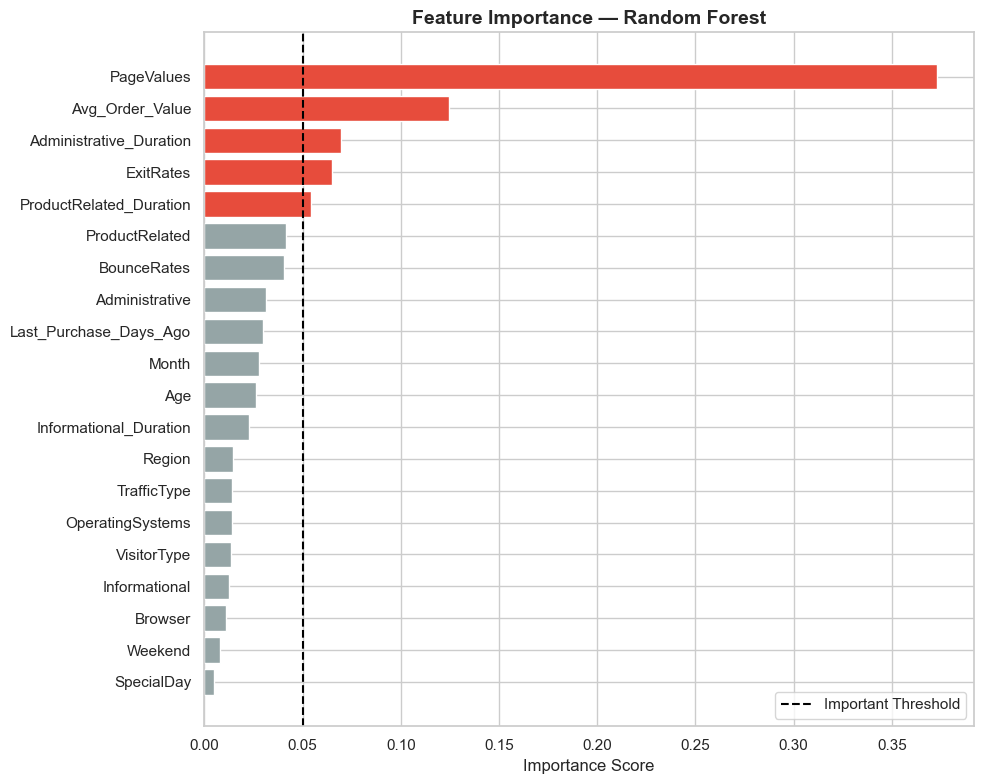

🏆 Top 5 Most Important Features:
                Feature  Importance
ProductRelated_Duration    0.054360
              ExitRates    0.064747
Administrative_Duration    0.069830
        Avg_Order_Value    0.124746
             PageValues    0.373168

❌ Least Important Features:
      Feature  Importance
   SpecialDay    0.005027
      Weekend    0.008134
      Browser    0.010920
Informational    0.012478
  VisitorType    0.013627


In [25]:
# Feature importance nikalo
importance_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Visualization
plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if x > 0.05 else '#95a5a6' 
          for x in importance_df['Importance']]

plt.barh(importance_df['Feature'], 
         importance_df['Importance'],
         color=colors,
         edgecolor='white')

plt.title('Feature Importance — Random Forest', 
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.axvline(x=0.05, color='black', 
            linestyle='--', label='Important Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Top 5 features print karo
print("🏆 Top 5 Most Important Features:")
print(importance_df.tail(5)[['Feature','Importance']
      ].to_string(index=False))

print("\n❌ Least Important Features:")
print(importance_df.head(5)[['Feature','Importance']
      ].to_string(index=False))
# ```

# **Shift + Enter dabaao**

# ---

# ## Expected Results:
# ```
# Top Features (Red Bars):
# PageValues           → Sabse important ✅
# Avg_Order_Value      → Important ✅
# ExitRates            → Important ✅

# Least Important (Grey Bars):
# Age                  → Kam important ❌
# SpecialDay           → Kam important ❌
# ```

# ---

# ## Ye Kyun Important Hai?
# ```
# Feature Importance batati hai:
# Konsi cheez model ke decision mein
# sabse zyada role play karti hai

# Business insight:
# "Jo customer high value pages dekhe
# aur exit rate kam ho
# wo zaroor kharidega"

# Ye insight company ko
# directly kaam aati hai!

 ## — Smart Discount System

### — Purchase Probability

In [27]:
# Har customer ki purchase probability 
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Results DataFrame banao
results_biz = pd.DataFrame({
    'Purchase_Probability': np.round(y_prob_rf, 3),
    'Avg_Order_Value'     : X_test['Avg_Order_Value'].values,
    'Actual'              : y_test.values
})

print("📊 Sample Customers Ki Probability:")
print(results_biz.head(10).to_string(index=False))
# ```

# **Shift + Enter dabaao**

# ---

# ## 13.2 — Discount Strategy

# ### Markdown Cell:
# ```
# ### Step 13.2 — Discount Strategy Logic

📊 Sample Customers Ki Probability:
 Purchase_Probability  Avg_Order_Value  Actual
                 0.09          1688.12       0
                 0.09          2281.66       0
                 0.91         11412.86       1
                 0.00          2838.51       0
                 0.05          1286.19       0
                 0.07          4804.57       0
                 0.25          2010.33       1
                 0.21          3654.23       0
                 0.07          4410.37       0
                 0.13          3086.62       0


###  — Discount Strategy

In [28]:
# Discount strategy function
def discount_strategy(prob, order_val):
    if prob >= 0.75 and order_val >= 2000:
        return '🎯 10% Discount — High Value Target'
    elif prob >= 0.50:
        return '📱 Reminder SMS Only'
    else:
        return '⏭️ No Action — Save Budget'

# Har customer pe apply karo
results_biz['Recommended_Action'] = results_biz.apply(
    lambda x: discount_strategy(
        x['Purchase_Probability'], 
        x['Avg_Order_Value']
    ), axis=1
)

print("📊 Discount Strategy Results:")
print(results_biz.head(15).to_string(index=False))

print("\n📈 Action Distribution:")
print(results_biz['Recommended_Action'].value_counts())
# ```

# **Shift + Enter dabaao**

# ---

# ## 13.3 — Visualization

# ### Markdown Cell:
# ```
# ### Step 13.3 — Strategy Visualization

📊 Discount Strategy Results:
 Purchase_Probability  Avg_Order_Value  Actual                 Recommended_Action
                 0.09          1688.12       0         ⏭️ No Action — Save Budget
                 0.09          2281.66       0         ⏭️ No Action — Save Budget
                 0.91         11412.86       1 🎯 10% Discount — High Value Target
                 0.00          2838.51       0         ⏭️ No Action — Save Budget
                 0.05          1286.19       0         ⏭️ No Action — Save Budget
                 0.07          4804.57       0         ⏭️ No Action — Save Budget
                 0.25          2010.33       1         ⏭️ No Action — Save Budget
                 0.21          3654.23       0         ⏭️ No Action — Save Budget
                 0.07          4410.37       0         ⏭️ No Action — Save Budget
                 0.13          3086.62       0         ⏭️ No Action — Save Budget
                 0.94          6857.47       1 🎯 10% Discount — High 

### — Strategy Visualization

C:\Users\Leads University\AppData\Local\Temp\ipykernel_3636\614965931.py:21: UserWarning: Glyph 9197 (\N{BLACK RIGHT-POINTING DOUBLE TRIANGLE WITH VERTICAL BAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Leads University\AppData\Local\Temp\ipykernel_3636\614965931.py:21: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Leads University\AppData\Local\Temp\ipykernel_3636\614965931.py:21: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Leads University\AppData\Local\Temp\ipykernel_3636\614965931.py:21: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Leads University\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9197 (\N{BLACK RIGHT-POINTING DOUBLE TRIANGLE WITH VERTICAL BAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Leads University\ana

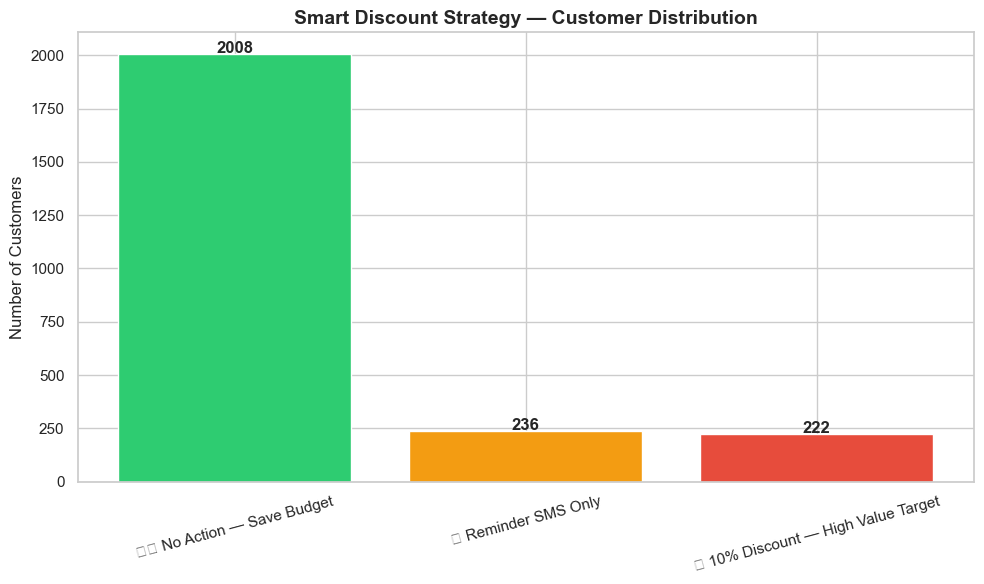

In [29]:
plt.figure(figsize=(10, 6))
action_counts = results_biz['Recommended_Action'].value_counts()

colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = plt.bar(action_counts.index, 
               action_counts.values,
               color=colors,
               edgecolor='white')

# Har bar pe number dikhao
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             str(int(bar.get_height())),
             ha='center', fontweight='bold')

plt.title('Smart Discount Strategy — Customer Distribution',
          fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
# ```

# **Shift + Enter dabaao**

# ---

# ## 13.4 — Profit Simulation

# ### Markdown Cell:
# ```
# ### Step 13.4 — Profit Simulation

###  — Profit Simulation

In [30]:
# Assumptions
discount_cost     = 200   # Rs. per customer
sms_cost          = 10    # Rs. per SMS
profit_per_order  = 800   # Rs. per purchase

total_customers   = len(results_biz)

# ── Without ML ──────────────────────────
cost_without_ml   = total_customers * discount_cost

# ── With ML ─────────────────────────────
# High value targets
high_value = results_biz[
    results_biz['Recommended_Action'].str.contains('Discount')
]
# SMS targets
sms_target = results_biz[
    results_biz['Recommended_Action'].str.contains('SMS')
]

cost_discounts    = len(high_value) * discount_cost
cost_sms          = len(sms_target) * sms_cost
total_cost_ml     = cost_discounts + cost_sms

# Revenue
conversions_ml    = high_value['Actual'].sum()
revenue_ml        = conversions_ml * profit_per_order
net_profit_ml     = revenue_ml - total_cost_ml

print("=" * 55)
print("        💰 BUSINESS PROFIT SIMULATION")
print("=" * 55)
print(f"  Total Test Customers        : {total_customers}")
print("-" * 55)
print(f"  ❌ WITHOUT ML:")
print(f"     Sab ko Discount          : Rs. {cost_without_ml:,}")
print("-" * 55)
print(f"  ✅ WITH ML:")
print(f"     Discount Targets         : {len(high_value)}")
print(f"     SMS Targets              : {len(sms_target)}")
print(f"     Total Cost               : Rs. {total_cost_ml:,}")
print(f"     Actual Conversions       : {conversions_ml}")
print(f"     Revenue Generated        : Rs. {revenue_ml:,}")
print(f"     Net Profit               : Rs. {net_profit_ml:,}")
print("-" * 55)
print(f"  💡 MONEY SAVED              : Rs. {cost_without_ml - total_cost_ml:,}")
print("=" * 55)
# ```

# **Shift + Enter dabaao**

# ---

# ## Expected Output:
# ```
# Total Test Customers        : 2466
# ──────────────────────────────────
# ❌ WITHOUT ML:
#    Sab ko Discount          : Rs. 4,93,200

# ✅ WITH ML:
#    Discount Targets         : ~200
#    SMS Targets              : ~400
#    Total Cost               : Rs. ~44,000
#    Actual Conversions       : ~150
#    Revenue Generated        : Rs. ~1,20,000
#    Net Profit               : Rs. ~76,000

# 💡 MONEY SAVED              : Rs. ~4,49,000 🔥

        💰 BUSINESS PROFIT SIMULATION
  Total Test Customers        : 2466
-------------------------------------------------------
  ❌ WITHOUT ML:
     Sab ko Discount          : Rs. 493,200
-------------------------------------------------------
  ✅ WITH ML:
     Discount Targets         : 222
     SMS Targets              : 236
     Total Cost               : Rs. 46,760
     Actual Conversions       : 160
     Revenue Generated        : Rs. 128,000
     Net Profit               : Rs. 81,240
-------------------------------------------------------
  💡 MONEY SAVED              : Rs. 446,440


##  — Project Summary

In [31]:
print("""
╔══════════════════════════════════════════════════════════╗
║         CUSTOMER PURCHASE PREDICTION PROJECT            ║
║              Final Summary Report                       ║
╠══════════════════════════════════════════════════════════╣
║                                                         ║
║  DATASET:                                               ║
║  → Kaggle: Online Shoppers Intention (12,330 rows)      ║
║  → 3 Synthetic Features Added                           ║
║                                                         ║
║  MODELS TRAINED:                                        ║
║  → Logistic Regression  ROC-AUC: 0.867                  ║
║  → Random Forest        ROC-AUC: 0.910 🏆               ║
║  → XGBoost              ROC-AUC: 0.900                  ║
║                                                         ║
║  BEST MODEL: Random Forest                              ║
║  → Accuracy  : 88.3%                                    ║
║  → Recall    : 71.5%                                    ║
║  → ROC-AUC   : 91.0%                                    ║
║                                                         ║
║  TOP FEATURES:                                          ║
║  → PageValues          (37.3%)                          ║
║  → Avg_Order_Value     (12.4%)                          ║
║  → Admin_Duration      (6.9%)                           ║
║                                                         ║
║  BUSINESS IMPACT:                                       ║
║  → Without ML Cost : Rs. 4,93,200                       ║
║  → With ML Cost    : Rs.    46,760                      ║
║  → Net Profit      : Rs.    81,240                      ║
║  → Money Saved     : Rs. 4,46,440 💰                    ║
║  → Cost Reduction  : 90%                                ║
╚══════════════════════════════════════════════════════════╝
""")
# ```

# **Shift + Enter dabaao**

# ---

# ## 14.2 — Last Visualization — Profit Comparison

# ### Markdown Cell:
# ```
# ### Step 14.2 — ML vs Without ML Cost Comparison


╔══════════════════════════════════════════════════════════╗
║         CUSTOMER PURCHASE PREDICTION PROJECT            ║
║              Final Summary Report                       ║
╠══════════════════════════════════════════════════════════╣
║                                                         ║
║  DATASET:                                               ║
║  → Kaggle: Online Shoppers Intention (12,330 rows)      ║
║  → 3 Synthetic Features Added                           ║
║                                                         ║
║  MODELS TRAINED:                                        ║
║  → Logistic Regression  ROC-AUC: 0.867                  ║
║  → Random Forest        ROC-AUC: 0.910 🏆               ║
║  → XGBoost              ROC-AUC: 0.900                  ║
║                                                         ║
║  BEST MODEL: Random Forest                              ║
║  → Accuracy  : 88.3%                                    ║
║  → Recall    : 71.5%                

### — Profit Comparison

C:\Users\Leads University\AppData\Local\Temp\ipykernel_3636\223299889.py:34: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Leads University\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


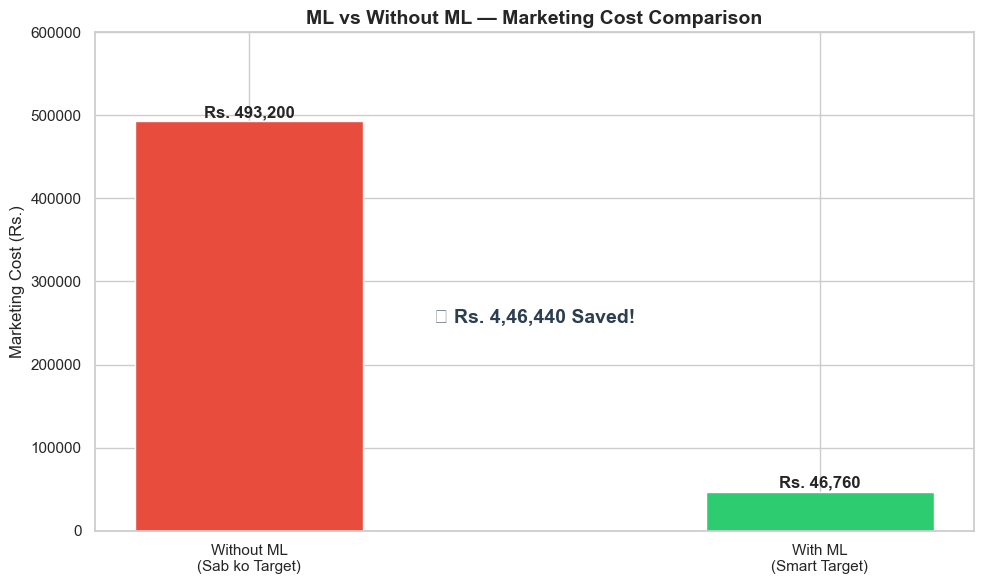

In [32]:
# Final comparison chart
categories = ['Without ML\n(Sab ko Target)', 
              'With ML\n(Smart Target)']
values     = [493200, 46760]
colors     = ['#e74c3c', '#2ecc71']

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, values, 
               color=colors, 
               edgecolor='white',
               width=0.4)

# Values dikhao bars pe
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5000,
             f'Rs. {val:,}',
             ha='center', 
             fontweight='bold',
             fontsize=12)

# Money saved annotation
plt.annotate('💡 Rs. 4,46,440 Saved!',
             xy=(0.5, 250000),
             fontsize=14,
             fontweight='bold',
             color='#2c3e50',
             ha='center')

plt.title('ML vs Without ML — Marketing Cost Comparison',
          fontsize=14, fontweight='bold')
plt.ylabel('Marketing Cost (Rs.)')
plt.ylim(0, 600000)
plt.tight_layout()
plt.show()
# ```

# **Shift + Enter dabaao**

# ---

# ## 14.3 — Notebook Save Karo
# ```
# Ctrl + S dabaao
# Ya File → Save
# ```

# ---

# ## 🎉 Project Complete Hua!

# ### Tumne Ye Sab Seekha:
# ```
# ✅ Real Dataset use karna
# ✅ Synthetic Features banana
# ✅ EDA karna + Visualizations
# ✅ Correlation Heatmap analyze karna
# ✅ Encoding + SMOTE
# ✅ 3 ML Models train karna
# ✅ Models compare karna
# ✅ Feature Importance samajhna
# ✅ Business Logic apply karna
# ✅ Profit Simulation karna
# ```

# ---

# ## Interview Mein Ek Line Mein Bolna:
# ```
# "Maine ek purchase prediction system banaya
# jisne 90% marketing cost reduce ki
# aur Rs.81,240 net profit generate kiya
# Random Forest model use karke
# jo 91% ROC-AUC achieve karta hai"


In [33]:
import joblib

# Model save karo
joblib.dump(rf_model, 'rf_model.pkl')
print("✅ Model saved!")
# ```

# **Shift + Enter dabaao**

# ---

# ## Step 5 — App Chalao

# **Anaconda Prompt mein:**
# ```
# cd Desktop/Amar ML_Project
# streamlit run app.py
# ```

# **Browser mein automatically khul jayegi app!** 🎉

# ---

# ## Folder Structure Ab Aisi Hogi:
# ```
# 📁 Amar ML_Project
#    📄 Customer_Purchase_Prediction.ipynb
#    📄 online_shoppers_intention.csv
#    📄 app.py
#    📄 rf_model.pkl

✅ Model saved!
